In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
results_df = pd.read_csv("football_results/results_v002.csv",encoding="utf-8")
goal_scorers_df = pd.read_csv("football_results/goalscorers.csv",encoding="utf-8")
shotout_df = pd.read_csv("football_results/shootouts.csv",encoding="utf-8")

In [3]:
results_df.shape

(49495, 9)

In [4]:
results_df.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [5]:
results_df.isna().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [6]:
results_df.shape

(49495, 9)

In [7]:
results_df["tournament"].value_counts()

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1054
                                        ...  
Copa Confraternidad                         1
Benedikt Fontana Cup                        1
ConIFA Challenger Cup                       1
CONIFA World Cup qualification              1
South Asian Super Cup                       1
Name: count, Length: 200, dtype: int64

In [8]:
results_df["neutral"].value_counts()

neutral
False    36358
True     13137
Name: count, dtype: int64

In [9]:
results_df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')

In [10]:
results_df = results_df.sort_values("date",ascending=True)
test_df = results_df.head(20)

In [11]:
unique_home_t = list(results_df["home_team"].unique())
unique_away_t = list(results_df["away_team"].unique())
all_t = unique_home_t + unique_away_t
all_t = np.array(all_t)
all_t = np.unique(all_t)

In [12]:
all_t

array(['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria',
       'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola',
       'Anguilla', 'Antigua and Barbuda', 'Arameans Suryoye', 'Argentina',
       'Armenia', 'Artsakh', 'Aruba', 'Asturias', 'Australia', 'Austria',
       'Aymara', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barawa', 'Barbados', 'Basque Country', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Biafra', 'Bolivia',
       'Bonaire', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brittany', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada',
       'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia',
       'Cayman Islands', 'Central African Republic', 'Central Spain',
       'Chad', 'Chagos Islands', 'Chameria', 'Chechnya', 'Chile', 'China',
       'Cilento', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Corsica', 'Costa Rica',

In [13]:
K_FACTORS = {
    "Friendly": 10,
    "British Home Championship": 25,
    "Évence Coppée Trophy": 10,
    "Muratti Vase": 10,
    "Copa Lipton": 15,
    "Copa Newton": 15,
    "Copa Premio Honor Argentino": 15,
    "Olympic Games": 25,
    "Copa Premio Honor Uruguayo": 15,
    "Far Eastern Championship Games": 15,
    "Copa Roca": 15,
    "Copa América": 50,
    "Inter-Allied Games": 10,
    "Peace Cup": 10,
    "Open International Championship": 10,
    "Soccer Ashes": 10,
    "Copa Chevallier Boutell": 15,
    "Nordic Championship": 20,
    "Central European International Cup": 30,
    "Baltic Cup": 20,
    "Balkan Cup": 20,
    "Central American and Caribbean Games": 15,
    "FIFA World Cup": 60,
    "Copa Rio Branco": 15,
    "FIFA World Cup qualification": 40,
    "Bolivarian Games": 15,
    "CCCF Championship": 25,
    "NAFC Championship": 25,
    "Copa Oswaldo Cruz": 15,
    "Asian Games": 20,
    "Pan American Championship": 20,
    "Copa del Pacífico": 15,
    "Copa Bernardo O'Higgins": 15,
    "AFC Asian Cup qualification": 35,
    "Atlantic Cup": 15,
    "AFC Asian Cup": 50,
    "African Cup of Nations": 50,
    "Copa Paz del Chaco": 15,
    "Merdeka Tournament": 15,
    "UEFA Euro qualification": 40,
    "Southeast Asian Peninsular Games": 15,
    "African Friendship Games": 10,
    "UEFA Euro": 50,
    "Windward Islands Tournament": 10,
    "African Cup of Nations qualification": 35,
    "Vietnam Independence Cup": 10,
    "Copa Carlos Dittborn": 15,
    "Phillip Seaga Cup": 10,
    "CONCACAF Championship": 45,
    "Copa Juan Pinto Durán": 15,
    "Arab Cup": 25,
    "South Pacific Games": 15,
    "Zambian Independence Tournament": 10,
    "CONCACAF Championship qualification": 30,
    "Copa Artigas": 15,
    "All-African Games": 20,
    "GaNEFo": 10,
    "Copa América qualification": 35,
    "King's Cup": 15,
    "Gulf Cup": 25,
    "Indonesia Tournament": 10,
    "Korea Cup": 15,
    "Palestine Cup": 10,
    "Brazil Independence Cup": 15,
    "Copa Ramón Castilla": 15,
    "Oceania Nations Cup": 40,
    "CECAFA Cup": 20,
    "Kuneitra Cup": 10,
    "Copa Félix Bogado": 10,
    "Real Madrid 75th Anniversary Cup": 10,
    "Beijing International Friendship Tournament": 10,
    "Southeast Asian Games": 15,
    "Kirin Cup": 15,
    "CFU Caribbean Cup qualification": 20,
    "CFU Caribbean Cup": 25,
    "Amílcar Cabral Cup": 15,
    "FIFA 75th Anniversary Cup": 10,
    "Indian Ocean Island Games": 10,
    "Guangzhou International Friendship Tournament": 10,
    "Mundialito": 20,
    "South Pacific Mini Games": 10,
    "West African Cup": 15,
    "Nehru Cup": 15,
    "Merlion Cup": 10,
    "Trans-Tasman Cup": 15,
    "Great Wall Cup": 10,
    "South Asian Games": 15,
    "UDEAC Cup": 15,
    "Rous Cup": 15,
    "CONMEBOL–UEFA Cup of Champions": 30,
    "Miami Cup": 10,
    "Lunar New Year Cup": 10,
    "Arab Cup qualification": 20,
    "Tournoi de France": 15,
    "Malta International Tournament": 10,
    "Four Nations Tournament": 10,
    "Matthews Cup": 10,
    "Tournament Burkina Faso": 10,
    "Marlboro Cup": 10,
    "Melanesia Cup": 15,
    "Island Games": 10,
    "NAFU Championship": 15,
    "Dynasty Cup": 15,
    "Dakar Tournament": 10,
    "UNCAF Cup": 25,
    "Scania 100 Tournament": 10,
    "Gold Cup": 45,
    "USA Cup": 10,
    "Jordan International Tournament": 10,
    "Confederations Cup": 40,
    "East Asian Games": 15,
    "United Arab Emirates Friendship Tournament": 10,
    "Joe Robbie Cup": 10,
    "Oceania Nations Cup qualification": 25,
    "Simba Tournament": 10,
    "SAFF Cup": 20,
    "AFF Championship": 25,
    "King Hassan II Tournament": 10,
    "Cyprus International Tournament": 10,
    "Dunhill Cup": 10,
    "COSAFA Cup qualification": 15,
    "COSAFA Cup": 20,
    "Gold Cup qualification": 30,
    "AFF Championship qualification": 20,
    "SKN Football Festival": 10,
    "Four Nations' Cup": 10,
    "UNIFFAC Cup": 15,
    "WAFF Championship": 20,
    "Millennium Cup": 10,
    "Cup of Ancient Civilizations": 10,
    "Prime Minister's Cup": 10,
    "Unity Cup": 10,
    "The Other Final": 10,
    "EAFF Championship": 25,
    "TIFOCO Tournament": 10,
    "Afro-Asian Games": 10,
    "AFC Challenge Cup": 20,
    "FIFI Wild Cup": 10,
    "ELF Cup": 10,
    "Viva World Cup": 10,
    "AFC Challenge Cup qualification": 15,
    "Coupe de l'Outre-Mer": 10,
    "VFF Cup": 10,
    "Corsica Cup": 10,
    "Dragon Cup": 10,
    "ABCS Tournament": 10,
    "Nile Basin Tournament": 10,
    "Nations Cup": 15,
    "Copa Confraternidad": 10,
    "Pacific Games": 15,
    "Superclásico de las Américas": 15,
    "Palestine International Championship": 10,
    "Philippine Peace Cup": 10,
    "Kirin Challenge Cup": 10,
    "International Tournament of Peoples, Cultures and Tribes": 10,
    "Tynwald Hill Tournament": 10,
    "OSN Cup": 10,
    "CONIFA World Football Cup": 10,
    "Niamh Challenge Cup": 10,
    "CONIFA European Football Cup": 10,
    "Benedikt Fontana Cup": 10,
    "ConIFA Challenger Cup": 10,
    "Hungary Heritage Cup": 10,
    "World Unity Cup": 10,
    "AFC Solidarity Cup": 15,
    "Pacific Mini Games": 10,
    "Intercontinental Cup": 15,
    "UEFA Nations League": 40,
    "CONCACAF Nations League qualification": 25,
    "Atlantic Heritage Cup": 10,
    "Inter Games": 10,
    "CONCACAF Nations League": 35,
    "CONIFA World Cup qualification": 10,
    "Three Nations Cup": 10,
    "Mahinda Rajapaksa Cup": 10,
    "Navruz Cup": 10,
    "CONIFA Africa Football Cup": 10,
    "CONIFA South America Football Cup": 10,
    "MSG Prime Minister's Cup": 10,
    "Tri Nation Tournament": 10,
    "CAFA Nations Cup": 20,
    "Mauritius Four Nations Cup": 10,
    "CONIFA World Football Cup qualification": 10,
    "CONIFA Asia Cup": 10,
    "FIFA Series": 10,
    "Marianas Cup": 10,
    "Tri-Nations Series": 10,
    "ASEAN Championship qualification": 20,
    "ASEAN Championship": 25,
    "EAFF Championship qualification": 15,
    "Mapinduzi Cup": 10,
    "Canadian Shield": 10,
    "Outrigger Challenge Cup": 10,
    "South Asian Super Cup": 10,
    "CONCACAF Series": 15,
    "Al Ain International Cup": 10,
    "Morocco, Capital of African Football": 10,
    "Mukuru 4 Nations": 10,
    "Diamond Jubilee International Football Tournament": 10,
    "Tri-Nations Cup": 10,
}

In [14]:
def get_k(tournament):
    return K_FACTORS.get(tournament, 10)

In [15]:
starting_elo = 1500
home_elos = []
away_elos = []
elos = {}
for t in all_t:
    elos[str(t)] = starting_elo
elos

for i in range(results_df.shape[0]):
    row = results_df.loc[i,:]
    
    tournament = row["tournament"]
    neutral = row["neutral"]
    
    home_t = row["home_team"]
    home_elo = elos[home_t]
    home_elos.append(home_elo)
    home_score = row["home_score"]
    
    away_t = row["away_team"]
    away_score = row["away_score"]
    away_elo = elos[away_t]
    away_elos.append(away_elo)

    if neutral == False:
        home_elo_adj = home_elo + 100
    else:
        home_elo_adj = home_elo

    p1_beats_p2 = 1/ (1+10**((away_elo-home_elo_adj)/400))
    p2_beats_p1 = 1 - p1_beats_p2

    k_constant = get_k(tournament)
    
    if home_score > away_score:
        winner = "home"
        s_home = 1
        s_away = 0
        
    elif home_score == away_score:
        winner = "draw"
        s_home = 0.5
        s_away = 0.5
        
    else:
        winner = "away"
        s_home = 0
        s_away = 1 

    home_r = k_constant * ( s_home - p1_beats_p2)
    away_r = k_constant * ( s_away - p2_beats_p1)

    home_elo = home_elo + home_r
    away_elo = away_elo + away_r

    elos[home_t] = home_elo
    elos[away_t] = away_elo

results_df["home_elo"] = home_elos
results_df["away_elo"] = away_elos

In [16]:
d = {}
d["team"] = elos.keys()
d["elo"] = elos.values()
elos_df = pd.DataFrame(d)

In [17]:
elos_df.sort_values("elo",ascending=False)

,team,elo
277,Spain,2074.883602
13,Argentina,2073.794400
102,France,2055.584932
91,England,1975.677539
39,Brazil,1973.008041
...,...,...
296,Timor-Leste,1067.070135
33,Bhutan,1063.511986
168,Macau,1050.127225
164,Liechtenstein,1008.570046


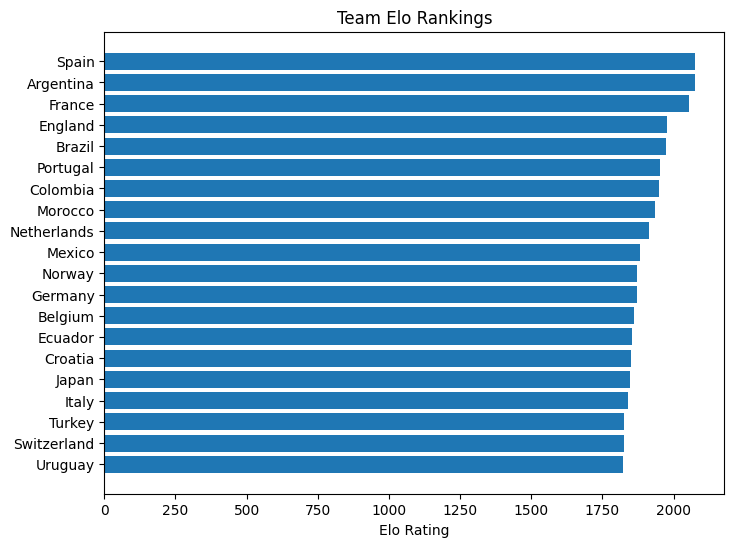

In [18]:
top20 = elos_df.sort_values("elo", ascending=False).head(20)
plt.figure(figsize=(8,6))
plt.barh(top20["team"], top20["elo"])
plt.gca().invert_yaxis()
plt.xlabel("Elo Rating")
plt.title("Team Elo Rankings")
plt.show()

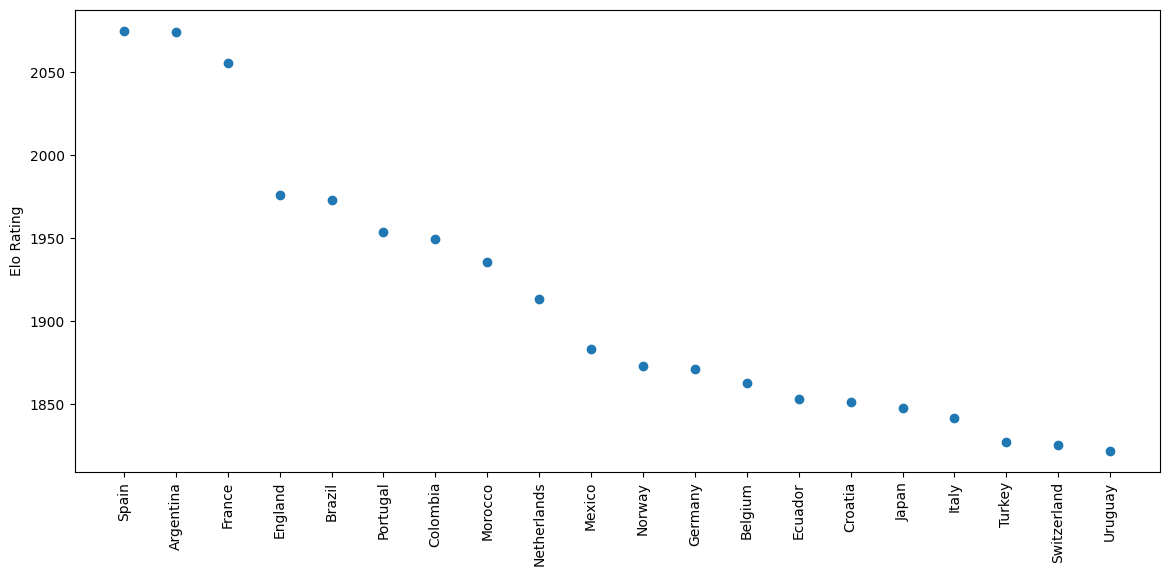

In [19]:
plt.figure(figsize=(14,6))
plt.scatter(top20["team"], top20["elo"])
plt.xticks(rotation=90)
plt.ylabel("Elo Rating")
plt.show()

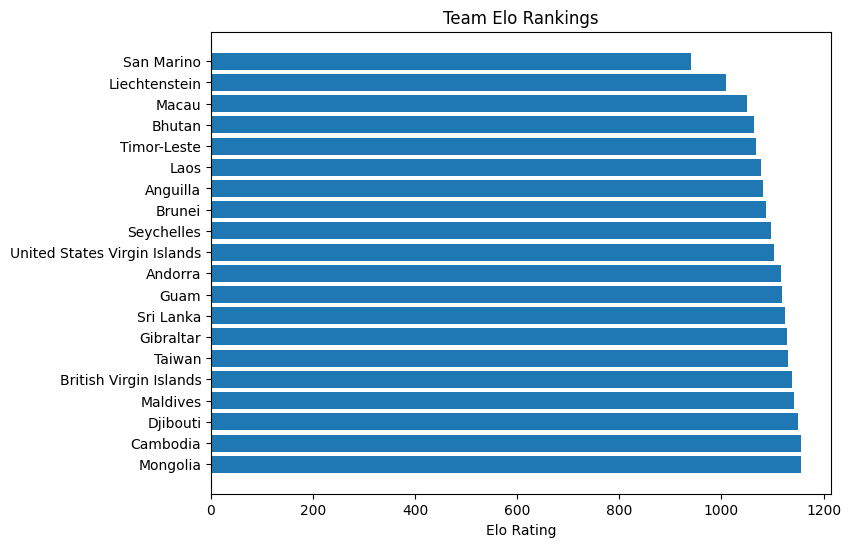

In [20]:
bot20 = elos_df.sort_values("elo", ascending=True).head(20)
plt.figure(figsize=(8,6))
plt.barh(bot20["team"], bot20["elo"])
plt.gca().invert_yaxis()
plt.xlabel("Elo Rating")
plt.title("Team Elo Rankings")
plt.show()

In [21]:
results_df.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1501.400650,1498.599350
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1495.037066,1504.962934
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1501.230923,1498.769077
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1500.202310,1499.797690


In [22]:
results_df = results_df.dropna()

In [23]:
results_df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1501.400650,1498.599350
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1495.037066,1504.962934
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1501.230923,1498.769077
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1500.202310,1499.797690
...,...,...,...,...,...,...,...,...,...,...,...
49490,2026-07-03,Australia,Egypt,1,1,FIFA World Cup,Arlington,United States,True,1819.723404,1793.955499
49491,2026-07-03,Argentina,Cape Verde,3,2,FIFA World Cup,Miami,United States,True,2068.374738,1667.149129
49492,2026-07-04,Colombia,Ghana,1,0,FIFA World Cup,Kansas City,United States,True,1940.010279,1645.080576
49493,2026-07-04,Canada,Morocco,0,3,FIFA World Cup,Houston,United States,True,1825.519405,1913.180355


In [24]:
all_ts = list(results_df["tournament"].unique())

In [25]:
# with open("tournamens.txt","w") as f:
#     for line in all_ts:
#         f.write(line)
#         f.write("\n")

In [26]:

        team_df["away_rolling_mean_3"] = team_df["away_score"].rolling(window=3).mean()
        team_df["home_rolling_mean_3"] = team_df["home_score"].rolling(window=3).mean()
        team_df["home_rolling_sum_3"] = team_df["home_score"].rolling(window=3).sum()
        team_df["away_rolling_sum_3"] = team_df["away_score"].rolling(window=3).sum()
        
        team_df["home_rolling_mean_5"] = team_df["home_score"].rolling(window=5).mean()
        team_df["away_rolling_mean_5"] = team_df["away_score"].rolling(window=5).mean()
        team_df["home_rolling_sum_5"] = team_df["home_score"].rolling(window=5).sum()
        team_df["away_rolling_sum_5"] = team_df["away_score"].rolling(window=5).sum()
    
        team_df["home_rolling_mean_10"] = team_df["home_score"].rolling(window=10).mean()
        team_df["away_rolling_mean_10"] = team_df["away_score"].rolling(window=10).mean()
        team_df["home_rolling_sum_10"] = team_df["home_score"].rolling(window=10).sum()
        team_df["away_rolling_sum_10"] = team_df["away_score"].rolling(window=10).sum()

In [42]:
##FEATURE ENGINEER
results_df["elo_diff"] = results_df["home_elo"] - results_df["away_elo"]

all_teams = list(elos.keys())[:1]

merged_df = pd.DataFrame()
for team in all_teams:
    home_team_rows = results_df[(results_df["home_team"] == team)]
    home_team_df = home_team_rows
    home_team_df["home_rolling_mean_3"] = home_team_df["home_score"].rolling(window=3).mean()
    home_team_df["home_rolling_sum_3"] = home_team_df["home_score"].rolling(window=3).sum()

    away_team_rows = results_df[(results_df["away_team"] == team)]
    away_team_df = away_team_rows
    away_team_df["away_rolling_mean_3"] = away_team_df["away_score"].rolling(window=3).mean()
    away_team_df["away_rolling_sum_3"] = away_team_df["away_score"].rolling(window=3).sum()

    team_df = pd.concat([home_team_df, away_team_df]).sort_values("date")
    team_df["rolling_mean_3"] = team_df["home_rolling_mean_3"].combine_first(team_df["away_rolling_mean_3"])
    team_df["rolling_sum_3"] = team_df["home_rolling_sum_3"].combine_first(team_df["away_rolling_sum_3"])
    
    print(team_df)
    

             date        home_team                away_team  home_score  \
36260  2012-09-25         Abkhazia                  Artsakh           1   
36404  2012-10-21          Artsakh                 Abkhazia           3   
37317  2013-09-23         Abkhazia            South Ossetia           3   
37791  2014-06-01         Abkhazia                Occitania           1   
37796  2014-06-02            Sápmi                 Abkhazia           1   
37823  2014-06-04         Abkhazia            South Ossetia           0   
37828  2014-06-05          Padania                 Abkhazia           3   
37852  2014-06-07         Abkhazia                Occitania           0   
38642  2015-05-05         Abkhazia               Luhansk PR           1   
38650  2015-05-14         Abkhazia               Donetsk PR           1   
39659  2016-05-21         Abkhazia               Donetsk PR           0   
39701  2016-05-29         Abkhazia           Chagos Islands           9   
39721  2016-05-31        

In [ ]:
results_df["elo_diff"] = results_df["home_elo"] - results_df["away_elo"]

all_teams = list(elos.keys())[:1]

merged_df = pd.DataFrame()

In [35]:
results_df.groupby('team')['goals']

KeyError: 'team'

In [28]:
from sklearn.preprocessing import LabelEncoder 
elo_cols = ["home_elo","away_elo"]

tourney_le = LabelEncoder()
ml_df = results_df.copy()
ml_df["tournament"] = tourney_le.fit_transform(ml_df["tournament"])

neu_le = LabelEncoder()
ml_df["neutral"] = neu_le.fit_transform(ml_df["neutral"])


In [29]:
results_df[(results_df['home_team']=='Italy') & (results_df['away_team']=='France') & (results_df['date']=='2006-07-09')]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,elo_diff
30111,2006-07-09,Italy,France,1,1,FIFA World Cup,Berlin,Germany,True,1942.553044,1947.11588,-4.562836
